# Segment-level metrics — 1BQF (`OneBitHHL`) up to 100 tracks

Recreates the standalone 2×2 segment-level figure from
[`segment_level_analysis.ipynb`](../Verify_new_results/segment_level_analysis.ipynb)
but replaces the classical Hopfield-style inversion with the **1BQF** (1-bit
quantum-block fixed-point / `OneBitHHL`) routine.

**Scope** — same parameters as the paper plot:
- $\gamma=3$, $\delta=1$, $\varepsilon=2$ mrad
- $\sigma_\mathrm{res}=5\,\mu\mathrm{m}$, $\sigma_\mathrm{scat}=10^{-4}$
- 5-layer plane geometry (`z = 33, 66, 99, 132, 165` mm, `±40` mm transverse)
- threshold $\tau=0.35$
- both **0 %** and **1 %** hit-drop conditions
- track counts $T \in \{2,4,6,8,10,15,20,30,40,50,60,75,100\}$
- **60 reps per (T, drop)** → 1 560 single-event jobs total

**Compute** — every event runs as a Condor GPU job that reuses the existing
[`condor_obqf/run_event.py`](../Verify_new_results/condor_obqf/run_event.py)
worker (1BQF on `AerSimulator(method='statevector', device='GPU')`,
`shots=8192`, `num_time_qubits=1`). The worker already writes `seg_C` and
`seg_Q` records §14-style, plus the raw solution vectors so we can later
re-threshold without re-running quantum jobs.

**Outputs** — paper-ready 2×2 figures and CSV tables under
`outputs/seg14_OneBQF/`.


## 1. Setup &mdash; paths, constants, sweep grid

Loads the §14 paper parameters and defines the (n_trk, drop, rep) sweep grid.
No heavy compute happens here.

In [1]:
from __future__ import annotations
import csv
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Paths ─────────────────────────────────────────────────────────
REPO_ROOT      = Path("/data/bfys/gscriven/Quantum_Track_Reconstruction")
PIPELINE_DIR   = REPO_ROOT / "Toy_Characterisation/Verify_new_results/condor_obqf"
RUN_EVENT_PY   = PIPELINE_DIR / "run_event.py"
SUBMIT_GPU_SUB = PIPELINE_DIR / "submit_gpu.sub"

NB_DIR  = REPO_ROOT / "Toy_Characterisation/Quantum_Toy_Study"

# ── Paper / §14 constants ─────────────────────────────────────────
GAMMA            = 2.0        # ← CHANGED from 3.0 to test if lower γ improves 1BQF
DELTA            = 1.0
FIXED_EPSILON    = 0.002      # 2 mrad
FIXED_RESOLUTION = 0.005      # 5 µm
FIXED_SCATTERING = 1e-4       # 0.1 mrad
SOLVER_THRESHOLD = 0.35

# §18e — OneBQF break-down curve with γ=2 (lower self-interaction penalty).
# Same grid as §18d but testing whether reduced γ improves 1BQF efficiency.
SOLVER_TRACK_COUNTS = [10, 15, 20, 30, 50, 75, 100, 150, 200, 300, 500]

def REPS_FOR_N(n: int) -> int:
    """Per-T rep count (taper above T=100 to keep wall time reasonable)."""
    if n < 100:   return 60
    if n < 300:   return 30
    return 20

# 1BQF / Aer config — single shot budget for the breakdown curve.
SHOTS_GRID       = [8192]
DEVICE           = "GPU"
DROP_RATES       = [0.0]

# ── Per-shots output directories ──────────────────────────────────
def _shots_root(shots: int) -> Path:
    return NB_DIR / f"outputs/seg18e_OneBQF_T500_gamma2_s{shots}"

OUT_DIRS = {s: _shots_root(s) for s in SHOTS_GRID}
RESULTS  = {(s, dr): OUT_DIRS[s] / f"drop{int(dr*100)}/results"
            for s in SHOTS_GRID for dr in DROP_RATES}
LOGS     = {(s, dr): OUT_DIRS[s] / f"drop{int(dr*100)}/logs"
            for s in SHOTS_GRID for dr in DROP_RATES}
PARAMS   = {(s, dr): OUT_DIRS[s] / f"params_seg18e_gamma2_drop{int(dr*100)}.csv"
            for s in SHOTS_GRID for dr in DROP_RATES}
PLOTS    = {s: OUT_DIRS[s] / "plots"  for s in SHOTS_GRID}
TABLES   = {s: OUT_DIRS[s] / "tables" for s in SHOTS_GRID}
COMPARE_DIR = NB_DIR / "outputs/seg18e_OneBQF_T500_gamma2"

for d in [*RESULTS.values(), *LOGS.values(), *PLOTS.values(),
          *TABLES.values(), COMPARE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

_total_jobs = sum(REPS_FOR_N(n) for n in SOLVER_TRACK_COUNTS) * len(DROP_RATES) * len(SHOTS_GRID)
print(f"Track grid  : {SOLVER_TRACK_COUNTS}  ({len(SOLVER_TRACK_COUNTS)} values)")
print(f"Reps        : " + ", ".join(f"T={n}:{REPS_FOR_N(n)}" for n in SOLVER_TRACK_COUNTS))
print(f"Drop rates  : {DROP_RATES}")
print(f"Device      : {DEVICE}")
print(f"Shots grid  : {SHOTS_GRID}")
print(f"Gamma (γ)   : {GAMMA}  ← TESTING LOWER PENALTY")
print(f"Total jobs  : {_total_jobs}")
print(f"Threshold   : τ = {SOLVER_THRESHOLD}")
for s in SHOTS_GRID:
    print(f"  shots={s}: outputs → {OUT_DIRS[s]}")


Track grid  : [10, 15, 20, 30, 50, 75, 100, 150, 200, 300, 500]  (11 values)
Reps        : T=10:60, T=15:60, T=20:60, T=30:60, T=50:60, T=75:60, T=100:30, T=150:30, T=200:30, T=300:20, T=500:20
Drop rates  : [0.0]
Device      : GPU
Shots grid  : [8192]
Gamma (γ)   : 2.0  ← TESTING LOWER PENALTY
Total jobs  : 490
Threshold   : τ = 0.35
  shots=8192: outputs → /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Quantum_Toy_Study/outputs/seg18e_OneBQF_T500_gamma2_s8192


In [2]:
"""
§18e diagnostic — threshold sensitivity analysis
Compare sol_C vs sol_Q_scaled entry distributions and
n_active_C vs n_active_Q across γ=2 and γ=3 pickles.
"""
import pickle, numpy as np, pandas as pd
from pathlib import Path

GAMMA2_DIR = Path("outputs/seg18e_OneBQF_T500_gamma2_s8192/drop0/results")
GAMMA3_DIR = Path("outputs/seg18d_OneBQF_T500_s8192/drop0/results")

THRESHOLD = 0.35

def load_threshold_stats(results_dir: Path, n_trk_list: list[int],
                          max_reps: int = 10) -> pd.DataFrame:
    """For each n_trk, load up to max_reps pickles and collect:
    - n_seg, n_active_C, n_active_Q (from fidelity dict)
    - median / p90 / max of sol_C entries
    - median / p90 / max of sol_Q_scaled entries
    """
    rows = []
    for n in n_trk_list:
        pkls = sorted(results_dir.glob(f"event_n{n:04d}_rep*.pkl"))[:max_reps]
        for p in pkls:
            with p.open("rb") as f:
                d = pickle.load(f)
            sol_C = np.asarray(d["sol_C"])
            sol_Q_raw = np.asarray(d["sol_Q_raw"])
            nC = float(np.linalg.norm(sol_C))
            nQ = float(np.linalg.norm(sol_Q_raw))
            sol_Q = sol_Q_raw * (nC / nQ) if nQ > 0 else sol_Q_raw
            rows.append(dict(
                n_trk=n, rep=d["rep"],
                n_seg=len(sol_C),
                # active counts
                n_active_C=int((sol_C > THRESHOLD).sum()),
                n_active_Q=int((sol_Q > THRESHOLD).sum()),
                # classical solution distribution
                med_C=float(np.median(sol_C)),
                p90_C=float(np.percentile(sol_C, 90)),
                max_C=float(sol_C.max()),
                # quantum solution distribution
                med_Q=float(np.median(sol_Q)),
                p90_Q=float(np.percentile(sol_Q, 90)),
                max_Q=float(sol_Q.max()),
                # fidelity
                cos=d["fidelity"]["cos"],
                n_seg_true=d["seg_C"]["n_true_all"],
            ))
    return pd.DataFrame(rows)

# Load stats for both γ values, small-to-medium T
DIAG_T = [10, 20, 50, 100]

print("Loading γ=2 ...")
df2 = load_threshold_stats(GAMMA2_DIR, DIAG_T, max_reps=10)
print("Loading γ=3 ...")
df3 = load_threshold_stats(GAMMA3_DIR, DIAG_T, max_reps=10)

print("\n── γ=2  (frac_active = n_active / n_seg) ──")
for n in DIAG_T:
    s = df2[df2.n_trk == n]
    if not len(s): continue
    print(f"  T={n:>3d}  n_seg={s.n_seg.mean():.0f}  "
          f"n_true={s.n_seg_true.mean():.1f}  "
          f"n_actC={s.n_active_C.mean():.1f}  n_actQ={s.n_active_Q.mean():.1f}  "
          f"max_C={s.max_C.mean():.3f}  p90_C={s.p90_C.mean():.3f}  "
          f"max_Q={s.max_Q.mean():.3f}  p90_Q={s.p90_Q.mean():.3f}  "
          f"cos={s.cos.mean():.3f}")

print("\n── γ=3 ──")
for n in DIAG_T:
    s = df3[df3.n_trk == n]
    if not len(s): continue
    print(f"  T={n:>3d}  n_seg={s.n_seg.mean():.0f}  "
          f"n_true={s.n_seg_true.mean():.1f}  "
          f"n_actC={s.n_active_C.mean():.1f}  n_actQ={s.n_active_Q.mean():.1f}  "
          f"max_C={s.max_C.mean():.3f}  p90_C={s.p90_C.mean():.3f}  "
          f"max_Q={s.max_Q.mean():.3f}  p90_Q={s.p90_Q.mean():.3f}  "
          f"cos={s.cos.mean():.3f}")


Loading γ=2 ...
Loading γ=3 ...

── γ=2  (frac_active = n_active / n_seg) ──
  T= 10  n_seg=400  n_true=40.0  n_actC=40.1  n_actQ=38.7  max_C=0.831  p90_C=0.384  max_Q=1.972  p90_Q=0.058  cos=0.553
  T= 20  n_seg=1600  n_true=80.0  n_actC=80.3  n_actQ=60.5  max_C=0.845  p90_C=0.333  max_Q=3.189  p90_Q=0.000  cos=0.375
  T= 50  n_seg=10000  n_true=200.0  n_actC=203.2  n_actQ=34.4  max_C=0.861  p90_C=0.333  max_Q=8.028  p90_Q=0.000  cos=0.122
  T=100  n_seg=40000  n_true=400.0  n_actC=421.1  n_actQ=21.1  max_C=1.258  p90_C=0.333  max_Q=17.105  p90_Q=0.000  cos=0.050

── γ=3 ──
  T= 10  n_seg=400  n_true=40.0  n_actC=40.0  n_actQ=34.6  max_C=0.455  p90_C=0.261  max_Q=1.463  p90_Q=0.000  cos=0.437
  T= 20  n_seg=1600  n_true=80.0  n_actC=80.0  n_actQ=45.2  max_C=0.455  p90_C=0.250  max_Q=2.529  p90_Q=0.000  cos=0.267
  T= 50  n_seg=10000  n_true=200.0  n_actC=200.0  n_actQ=25.3  max_C=0.455  p90_C=0.250  max_Q=6.960  p90_Q=0.000  cos=0.085
  T=100  n_seg=40000  n_true=400.0  n_actC=401.7  

## 2. Generate Condor parameter CSVs &mdash; both drop conditions

Writes one row per `(n_trk, rep, shots, device, drop_rate)` combination
into the two parameter files consumed by the GPU submit file. Skips
rows that already have a result pickle on disk so reruns only fill
in missing events.

In [9]:
def _result_pkl(results_dir: Path, n_trk: int, rep: int) -> Path:
    """Filename produced by run_event.py for a given (n_trk, rep)."""
    return results_dir / f"event_n{n_trk:04d}_rep{rep:03d}.pkl"


def write_param_csv(shots: int, drop_rate: float,
                    force: bool = False) -> tuple[Path, int, int]:
    """Emit param CSV for a given (shots, drop_rate); skip rows already on disk."""
    results_dir = RESULTS[(shots, drop_rate)]
    csv_path    = PARAMS[(shots, drop_rate)]
    rows, done  = [], 0
    for n in SOLVER_TRACK_COUNTS:
        for rep in range(REPS_FOR_N(n)):
            if not force and _result_pkl(results_dir, n, rep).exists():
                done += 1
                continue
            rows.append((n, rep, shots, DEVICE, drop_rate, GAMMA))
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    with csv_path.open("w", newline="") as f:
        csv.writer(f).writerows(rows)
    return csv_path, len(rows), done


for s in SHOTS_GRID:
    for dr in DROP_RATES:
        csv_path, n_new, n_done = write_param_csv(s, dr)
        print(f"shots={s:>5}  drop={dr:>4}:  {n_new:4d} new jobs  "
              f"({n_done} cached)  →  {csv_path.name}")


shots= 8192  drop= 0.0:   490 new jobs  (0 cached)  →  params_seg18e_gamma2_drop0.csv


## 3. Submit the Condor GPU sweep

The submit file [`condor_obqf/submit_gpu.sub`](../Verify_new_results/condor_obqf/submit_gpu.sub)
is reused as-is &mdash; one job per CSV row, each requesting `1 GPU + 32 GB
RAM` (`GPUs_Capability ≥ 7.0`). Each job invokes
[`run_event.py`](../Verify_new_results/condor_obqf/run_event.py), which
generates the event with the §14-identical seed
`np.random.seed(rep + n_trk*100 + 140000)`, optionally applies the 1 %
hit drop, runs both the classical solve and the 1BQF (`OneBitHHL`) solve
on GPU, and writes one pickle per event.

Run the two cells below from a terminal (they intentionally **do not**
auto-submit &mdash; submitting from the notebook kernel would orphan the
jobs if the kernel dies).

```bash
cd /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Verify_new_results

# 0 % hit drop
condor_submit \
  -append "PARAMS_CSV=/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Quantum_Toy_Study/outputs/seg14_OneBQF/params_seg14_drop0.csv" \
  -append "RESULTSDIR=/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Quantum_Toy_Study/outputs/seg14_OneBQF/drop0/results" \
  -append "LOGDIR=/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Quantum_Toy_Study/outputs/seg14_OneBQF/drop0/logs" \
  condor_obqf/submit_gpu.sub

# 1 % hit drop
condor_submit \
  -append "PARAMS_CSV=/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Quantum_Toy_Study/outputs/seg14_OneBQF/params_seg14_drop1.csv" \
  -append "RESULTSDIR=/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Quantum_Toy_Study/outputs/seg14_OneBQF/drop1/results" \
  -append "LOGDIR=/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Quantum_Toy_Study/outputs/seg14_OneBQF/drop1/logs" \
  condor_obqf/submit_gpu.sub
```

Monitor with `condor_q $USER`. Re-running cell 4 after the queue
drains will only emit param rows for events that are still missing,
so partial sweeps are safe to top up.

In [10]:
# Convenience: print the exact submit commands for copy-paste
# (one per (shots, drop_rate) combination).
for s in SHOTS_GRID:
    for dr in DROP_RATES:
        print(f"\n# shots={s}, {dr*100:.0f}% hit drop")
        print("condor_submit \\")
        print(f"  -append \"PARAMS_CSV={PARAMS[(s, dr)]}\" \\")
        print(f"  -append \"RESULTSDIR={RESULTS[(s, dr)]}\" \\")
        print(f"  -append \"LOGDIR={LOGS[(s, dr)]}\" \\")
        print(f"  {SUBMIT_GPU_SUB}")



# shots=8192, 0% hit drop
condor_submit \
  -append "PARAMS_CSV=/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Quantum_Toy_Study/outputs/seg18e_OneBQF_T500_gamma2_s8192/params_seg18e_gamma2_drop0.csv" \
  -append "RESULTSDIR=/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Quantum_Toy_Study/outputs/seg18e_OneBQF_T500_gamma2_s8192/drop0/results" \
  -append "LOGDIR=/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Quantum_Toy_Study/outputs/seg18e_OneBQF_T500_gamma2_s8192/drop0/logs" \
  /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Verify_new_results/condor_obqf/submit_gpu.sub


## 4. Local cross-check at small T

Before launching the full sweep, run a single $T=2$ event locally
(CPU is plenty for 2 tracks). Confirms (a) the worker is reachable
and (b) the classical-only path matches the §14 paper plot value
at small T (where it is essentially $100\,\%$ efficient).

This cell is independent &mdash; skip it if you have already cached
results.

In [16]:
import sys, importlib.util

# Hot-load run_event.py from the existing pipeline (no install required).
_spec = importlib.util.spec_from_file_location("seg14_run_event", RUN_EVENT_PY)
_mod  = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)

# Cross-check at T=2 for both shot budgets.
print(f"Cross-check: T=2, rep=0, drop=0%, device=CPU (local)")
for s in SHOTS_GRID:
    out = _mod.run_job(n_trk=2, rep=0, shots=s, device="CPU",
                       epsilon=FIXED_EPSILON, gamma=GAMMA, delta=DELTA,
                       sigma_res=FIXED_RESOLUTION, sigma_scatt=FIXED_SCATTERING,
                       threshold=SOLVER_THRESHOLD, drop_rate=0.0)
    segC = out["seg_C"]; segQ = out["seg_Q"]
    effC = 100 * segC["n_true_active"] / max(segC["n_true_clean"], 1)
    effQ = 100 * segQ["n_true_active"] / max(segQ["n_true_clean"], 1)
    print(f"\n  shots = {s}")
    print(f"    n_seg            = {out['n_seg']}")
    print(f"    classical eff    = {effC:6.2f} %")
    print(f"    1BQF eff         = {effQ:6.2f} %")
    print(f"    cos(C, Q)        = {out['fidelity']['cos']:.4f}")
    print(f"    Jaccard@τ=0.35   = {out['fidelity']['jaccard']:.4f}")
    print(f"    P(ancilla=1)     = {out['success_prob']:.4f}")
    print(f"    t_C / t_Q        = {out['t_classical']:.3f} s / {out['t_quantum']:.3f} s")
    assert effC > 99.0, f"§14 cross-check failed at shots={s}: effC={effC:.2f}%"
print("\n✓ Cross-check passed for all shot budgets.")


Cross-check: T=2, rep=0, drop=0%, device=CPU (local)

  shots = 8192
    n_seg            = 16
    classical eff    = 100.00 %
    1BQF eff         =  75.00 %
    cos(C, Q)        = 0.8288
    Jaccard@τ=0.35   = 0.7500
    P(ancilla=1)     = 0.1418
    t_C / t_Q        = 0.002 s / 0.159 s

  shots = 81920
    n_seg            = 16
    classical eff    = 100.00 %
    1BQF eff         =  75.00 %
    cos(C, Q)        = 0.8266
    Jaccard@τ=0.35   = 0.7500
    P(ancilla=1)     = 0.1435
    t_C / t_Q        = 0.000 s / 0.187 s

✓ Cross-check passed for all shot budgets.


## 5. Aggregate cached event pickles

Each Condor job writes one pickle:
`event_n{N:04d}_rep{R:03d}.pkl`. Each pickle stores the **raw** 1BQF
solution vector (`sol_Q_raw`, `sol_Q_scaled`) alongside the §14-style
segment record (`seg_Q`, `seg_C`) computed at $\tau=0.35$ &mdash; so we
can re-threshold later without rerunning quantum jobs.

This cell loads everything that's currently on disk, builds a long
`pandas.DataFrame`, and aggregates per `(n_trk, who)` &mdash; identical
math to §14's `_agg_solver`.

In [2]:
def _sem(a):
    a = np.asarray(a, dtype=float)
    return float(a.std(ddof=1) / np.sqrt(len(a))) if len(a) > 1 else 0.0


def load_long_df(shots: int, drop_rate: float) -> pd.DataFrame:
    """Load all per-event pickles for a (shots, drop_rate) pair."""
    rows = []
    pkls = sorted(RESULTS[(shots, drop_rate)].glob("event_n*_rep*.pkl"))
    for p in pkls:
        try:
            with p.open("rb") as f:
                d = pickle.load(f)
        except Exception as exc:
            print(f"  [skip] {p.name}: {exc}")
            continue
        for who, key in (("C", "seg_C"), ("Q", "seg_Q")):
            s = d[key]
            n_true = max(int(s["n_true_clean"]), 1)
            n_act  = max(int(s["n_active"]),     1)
            rows.append(dict(
                shots=shots,
                n_trk=int(d["n_trk"]), rep=int(d["rep"]), who=who,
                drop_rate=float(d["drop_rate"]),
                n_true_all=int(s["n_true_all"]),
                n_true_clean=int(s["n_true_clean"]),
                n_false_all=int(s["n_false_all"]),
                n_active=int(s["n_active"]),
                n_true_active=int(s["n_true_active"]),
                n_false_active=int(s["n_false_active"]),
                eff_pct=100.0 * s["n_true_active"] / n_true,
                fr_pct =100.0 * s["n_false_active"] / n_act,
                cos=float(d["fidelity"]["cos"]),
                jaccard=float(d["fidelity"]["jaccard"]),
                t_classical=float(d["t_classical"]),
                t_quantum  =float(d["t_quantum"]),
                success_prob=float(d["success_prob"]),
                n_seg=int(d["n_seg"]),
            ))
    return pd.DataFrame(rows)


def aggregate(df: pd.DataFrame) -> pd.DataFrame:
    """§14-style mean+SEM per (n_trk, who)."""
    if not len(df):
        return df
    g = (df
         .groupby(["who", "n_trk"], as_index=False)
         .agg(eff_m=("eff_pct", "mean"),       eff_e=("eff_pct", _sem),
              fr_m =("fr_pct",  "mean"),       fr_e =("fr_pct",  _sem),
              ntm  =("n_true_all",   "mean"),  ntse=("n_true_all",   _sem),
              nfm  =("n_false_all",  "mean"),  nfse=("n_false_all",  _sem),
              tam  =("n_true_active","mean"),  tase=("n_true_active",_sem),
              fam  =("n_false_active","mean"), fase=("n_false_active",_sem),
              n_reps=("rep", "count")))
    return g.sort_values(["who", "n_trk"]).reset_index(drop=True)


# nested dict: {shots: {drop_rate: df}}
long_df = {s: {dr: load_long_df(s, dr) for dr in DROP_RATES}
           for s in SHOTS_GRID}
agg_df  = {s: {dr: aggregate(long_df[s][dr]) for dr in DROP_RATES}
           for s in SHOTS_GRID}

n_exp = sum(REPS_FOR_N(n) for n in SOLVER_TRACK_COUNTS)
for s in SHOTS_GRID:
    print(f"\n══ shots = {s} ══")
    for dr in DROP_RATES:
        ldf = long_df[s][dr]
        n_evt = len(ldf) // 2 if len(ldf) else 0
        print(f"  drop={dr:>4}:  {n_evt}/{n_exp} events  "
              f"({100*n_evt/max(n_exp,1):.1f}%)")
        if len(agg_df[s][dr]):
            for n in SOLVER_TRACK_COUNTS:
                sub = agg_df[s][dr][agg_df[s][dr].n_trk == n]
                if len(sub):
                    rC = sub[sub.who == "C"]; rQ = sub[sub.who == "Q"]
                    if len(rC) and len(rQ):
                        print(f"     T={n:>3d}  reps={int(rC.n_reps.iloc[0]):>2d}  "
                              f"effC={float(rC.eff_m.iloc[0]):6.2f}±{float(rC.eff_e.iloc[0]):4.2f}%  "
                              f"effQ={float(rQ.eff_m.iloc[0]):6.2f}±{float(rQ.eff_e.iloc[0]):4.2f}%   "
                              f"frC={float(rC.fr_m.iloc[0]):5.2f}%   "
                              f"frQ={float(rQ.fr_m.iloc[0]):5.2f}%")



══ shots = 8192 ══
  drop= 0.0:  486/490 events  (99.2%)
     T= 10  reps=60  effC=100.00±0.00%  effQ= 96.83±0.35%   frC= 0.04%   frQ= 0.04%
     T= 15  reps=60  effC=100.00±0.00%  effQ= 89.17±0.48%   frC= 0.11%   frQ= 0.12%
     T= 20  reps=60  effC=100.00±0.00%  effQ= 73.04±0.59%   frC= 0.14%   frQ= 0.14%
     T= 30  reps=60  effC=100.00±0.00%  effQ= 51.99±0.53%   frC= 0.46%   frQ= 0.43%
     T= 50  reps=60  effC=100.00±0.00%  effQ= 18.15±0.34%   frC= 1.12%   frQ= 0.78%
     T= 75  reps=60  effC= 99.91±0.06%  effQ=  9.76±0.26%   frC= 2.86%   frQ= 2.05%
     T=100  reps=30  effC= 99.93±0.07%  effQ=  4.77±0.19%   frC= 4.87%   frQ= 3.61%
     T=150  reps=30  effC= 99.91±0.06%  effQ=  2.47±0.11%   frC= 9.84%   frQ= 6.33%
     T=200  reps=30  effC= 99.97±0.03%  effQ=  1.12±0.06%   frC=15.81%   frQ=11.85%
     T=300  reps=20  effC= 99.97±0.03%  effQ=  0.62±0.06%   frC=30.25%   frQ=26.24%
     T=500  reps=16  effC= 99.92±0.04%  effQ=  0.29±0.03%   frC=55.02%   frQ=50.14%


## 6. Save intermediate tables

Long and aggregated tables go to CSV so the analysis can be revisited
without rerunning anything &mdash; or with a different threshold (the raw
`sol_Q_raw` vectors are still in the per-event pickles).

In [3]:
for s in SHOTS_GRID:
    for dr in DROP_RATES:
        tag = f"drop{int(dr*100)}"
        if len(long_df[s][dr]):
            long_df[s][dr].to_csv(TABLES[s] / f"seg14_OneBQF_s{s}_{tag}_events.csv",
                                  index=False)
            agg_df[s][dr].to_csv(TABLES[s] / f"seg14_OneBQF_s{s}_{tag}_agg.csv",
                                 index=False)
            print(f"  shots={s}  drop={dr}:  wrote events + agg CSVs to {TABLES[s]}/")
        else:
            print(f"  shots={s}  drop={dr}:  no cached events (skipped)")


  shots=8192  drop=0.0:  wrote events + agg CSVs to /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Quantum_Toy_Study/outputs/seg18e_OneBQF_T500_gamma2_s8192/tables/


## 7. Publication-ready 2&times;2 figure

For each drop condition, draw the §14e standalone 2&times;2 plot but
overlaying the **1BQF** solver alongside the classical solver:

- (i)   Segment efficiency  $N_\mathrm{true\,act}/N_\mathrm{true\,all}$
- (ii)  Segment false rate  $N_\mathrm{false\,act}/N_\mathrm{accepted}$
- (iii) Segment pair counts (true / false, log-log)
- (iv)  Active segment pairs (true / false, log-log)

Solver-agnostic counts (truth / total segments) are drawn once. Threshold
fixed at $\tau = 0.35$.


── drop_rate = 0% ──
  saved /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Quantum_Toy_Study/outputs/seg18e_OneBQF_T500_gamma2/seg14_OneBQF_compare_drop0.{pdf,png}


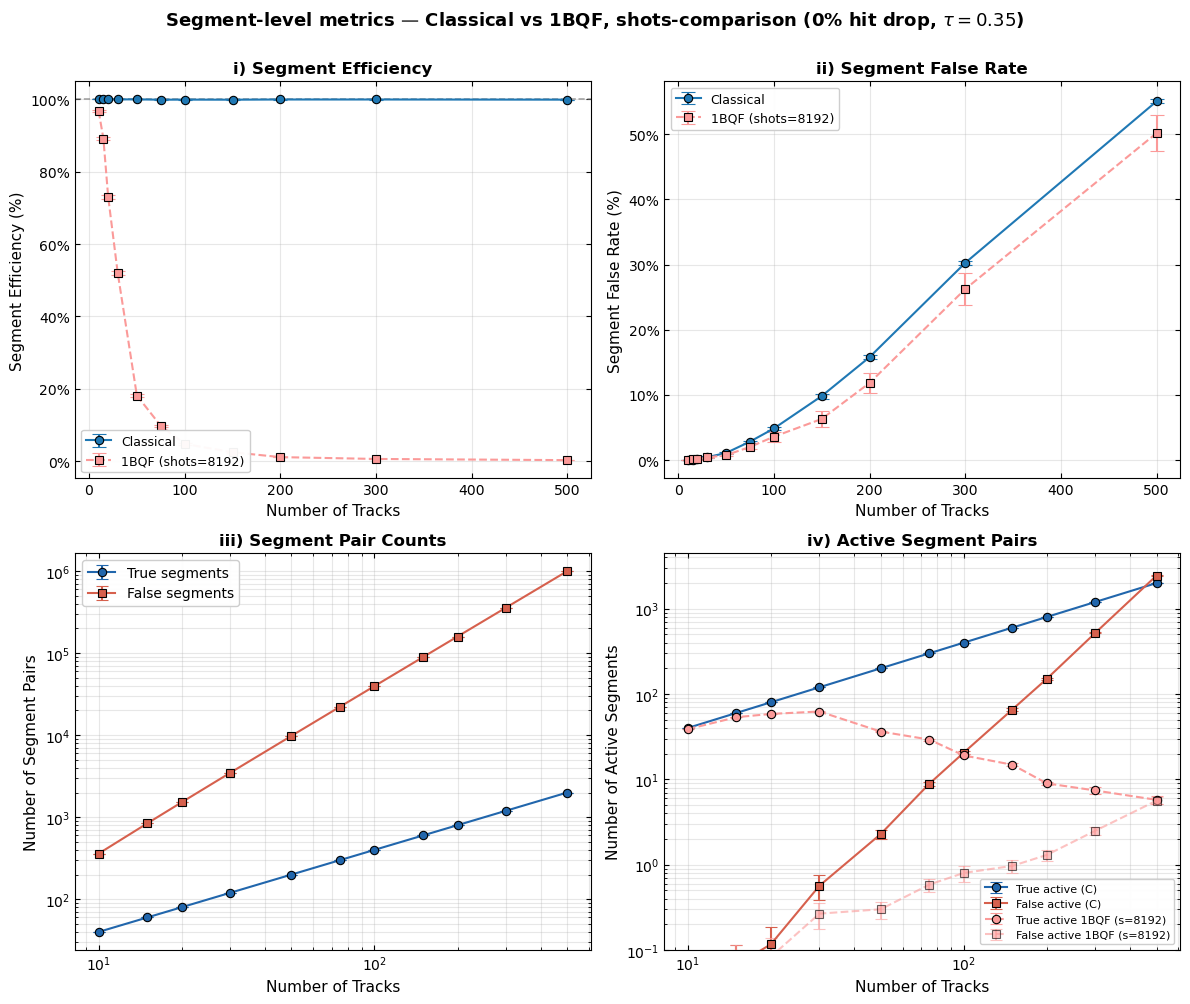

In [4]:
# ── colours mirror §14 palette ──────────────────────────────────────
C_COL = "#1f78b4"   # classical (same for both shot budgets — should overlap)
# Q overlays: darker for fewer shots, brighter for more
Q_COL = {8192: "#fb9a99", 81920: "#e31a1c"}
TRUE_COL  = "#2166ac"
FALSE_COL = "#d6604d"


def _safe(y):
    y = np.asarray(y, dtype=float)
    return np.where(y > 0, y, 0.5)


def plot_seg_2x2_compare(drop_rate: float, save: bool = True) -> Path | None:
    """Overlay 1BQF results for every shot budget in SHOTS_GRID."""
    have_any = False
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Pick any non-empty C row for the truth/total counts (panel iii).
    any_C = None
    for s in SHOTS_GRID:
        g = agg_df[s][drop_rate]
        if len(g) and len(g[g.who == "C"]):
            any_C = g[g.who == "C"].sort_values("n_trk").reset_index(drop=True)
            break
    if any_C is None:
        print(f"[drop={drop_rate}]  no data — skipped"); return None

    # i) Segment efficiency  (one C curve, one Q curve per shot budget)
    ax = axes[0, 0]
    plotted_C = False
    for s in SHOTS_GRID:
        g = agg_df[s][drop_rate]
        if not len(g): continue
        dC = g[g.who == "C"].sort_values("n_trk").reset_index(drop=True)
        dQ = g[g.who == "Q"].sort_values("n_trk").reset_index(drop=True)
        if not plotted_C and len(dC):
            ax.errorbar(dC.n_trk, dC.eff_m, yerr=dC.eff_e, fmt="o-", color=C_COL,
                        capsize=5, capthick=1.5, markeredgecolor="black",
                        markeredgewidth=0.8, label="Classical", zorder=3)
            plotted_C = True
        if len(dQ):
            ax.errorbar(dQ.n_trk, dQ.eff_m, yerr=dQ.eff_e, fmt="s--",
                        color=Q_COL.get(s, "k"),
                        capsize=5, capthick=1.5, markeredgecolor="black",
                        markeredgewidth=0.8, label=f"1BQF (shots={s})", zorder=3)
            have_any = True
    ax.axhline(100, color="gray", ls="--", lw=1.2, alpha=0.7, zorder=2)
    ax.set_ylabel("Segment Efficiency (%)", fontsize=11)
    ax.set_title(r"i) Segment Efficiency",
                 fontweight="bold")
    ax.grid(True, alpha=0.3, zorder=1)
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%g%%"))
    ax.legend(loc="lower left", framealpha=0.95, fontsize=9)

    # ii) Segment false rate
    ax = axes[0, 1]
    plotted_C = False
    for s in SHOTS_GRID:
        g = agg_df[s][drop_rate]
        if not len(g): continue
        dC = g[g.who == "C"].sort_values("n_trk").reset_index(drop=True)
        dQ = g[g.who == "Q"].sort_values("n_trk").reset_index(drop=True)
        if not plotted_C and len(dC):
            ax.errorbar(dC.n_trk, dC.fr_m, yerr=dC.fr_e, fmt="o-", color=C_COL,
                        capsize=5, capthick=1.5, markeredgecolor="black",
                        markeredgewidth=0.8, label="Classical", zorder=3)
            plotted_C = True
        if len(dQ):
            ax.errorbar(dQ.n_trk, dQ.fr_m, yerr=dQ.fr_e, fmt="s--",
                        color=Q_COL.get(s, "k"),
                        capsize=5, capthick=1.5, markeredgecolor="black",
                        markeredgewidth=0.8, label=f"1BQF (shots={s})", zorder=3)
    ax.set_ylabel("Segment False Rate (%)", fontsize=11)
    ax.set_title("ii) Segment False Rate", fontweight="bold")
    ax.grid(True, alpha=0.3, zorder=1)
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%g%%"))
    ax.legend(loc="upper left", framealpha=0.95, fontsize=9)

    # iii) Segment pair counts (truth-only, solver-agnostic)
    ax = axes[1, 0]
    ax.errorbar(any_C.n_trk, any_C.ntm, yerr=any_C.ntse, fmt="o-",
                color=TRUE_COL, capsize=4, capthick=1.2,
                markeredgecolor="black", markeredgewidth=0.8,
                label="True segments", zorder=3)
    ax.errorbar(any_C.n_trk, any_C.nfm, yerr=any_C.nfse, fmt="s-",
                color=FALSE_COL, capsize=4, capthick=1.2,
                markeredgecolor="black", markeredgewidth=0.8,
                label="False segments", zorder=3)
    ax.set_yscale("log")
    ax.set_ylabel("Number of Segment Pairs", fontsize=11)
    ax.set_title("iii) Segment Pair Counts", fontweight="bold")
    ax.legend(loc="upper left", framealpha=0.95, fontsize=10)
    ax.grid(True, alpha=0.3, which="both", zorder=1)
    ax.minorticks_on(); ax.tick_params(which="both", direction="in",
                                       top=True, right=True)

    # iv) Active segment pairs — C once, Q overlaid per shot budget
    ax = axes[1, 1]
    plotted_C_act = False
    for s in SHOTS_GRID:
        g = agg_df[s][drop_rate]
        if not len(g): continue
        dC = g[g.who == "C"].sort_values("n_trk").reset_index(drop=True)
        dQ = g[g.who == "Q"].sort_values("n_trk").reset_index(drop=True)
        if not plotted_C_act and len(dC):
            ax.errorbar(dC.n_trk, _safe(dC.tam), yerr=dC.tase, fmt="o-",
                        color=TRUE_COL, capsize=4, capthick=1.2,
                        markeredgecolor="black", markeredgewidth=0.8,
                        label="True active (C)", zorder=3)
            ax.errorbar(dC.n_trk, _safe(dC.fam), yerr=dC.fase, fmt="s-",
                        color=FALSE_COL, capsize=4, capthick=1.2,
                        markeredgecolor="black", markeredgewidth=0.8,
                        label="False active (C)", zorder=3)
            plotted_C_act = True
        if len(dQ):
            ax.errorbar(dQ.n_trk, _safe(dQ.tam), yerr=dQ.tase, fmt="o--",
                        color=Q_COL.get(s, "k"),
                        capsize=4, capthick=1.2, markeredgecolor="black",
                        markeredgewidth=0.8,
                        label=f"True active 1BQF (s={s})", zorder=3)
            ax.errorbar(dQ.n_trk, _safe(dQ.fam), yerr=dQ.fase, fmt="s--",
                        color=Q_COL.get(s, "k"), alpha=0.6,
                        capsize=4, capthick=1.2, markeredgecolor="black",
                        markeredgewidth=0.8,
                        label=f"False active 1BQF (s={s})", zorder=3)
    ax.set_yscale("log"); ax.set_ylim(0.1, None)
    ax.set_ylabel("Number of Active Segments", fontsize=11)
    ax.set_title("iv) Active Segment Pairs", fontweight="bold")
    ax.legend(loc="lower right", framealpha=0.95, fontsize=8)
    ax.grid(True, alpha=0.3, which="both", zorder=1)
    ax.minorticks_on(); ax.tick_params(which="both", direction="in",
                                       top=True, right=True)

    for ax in axes.flat:
        ax.set_xlabel("Number of Tracks", fontsize=11)
    for ax in axes[1, :]:
        ax.set_xscale("log")

    drop_lbl = f"{drop_rate*100:.0f}%"
    fig.suptitle(rf"Segment-level metrics — Classical vs 1BQF, shots-comparison "
                 rf"({drop_lbl} hit drop, $\tau={SOLVER_THRESHOLD}$)",
                 fontsize=13, fontweight="bold", y=1.00)
    fig.tight_layout()

    if save and have_any:
        stem = f"seg14_OneBQF_compare_drop{int(drop_rate*100)}"
        for ext in ("pdf", "png"):
            fig.savefig(COMPARE_DIR / f"{stem}.{ext}",
                        dpi=600 if ext == "pdf" else 300,
                        bbox_inches="tight", facecolor="white")
        print(f"  saved {COMPARE_DIR / stem}.{{pdf,png}}")
    plt.show()
    return COMPARE_DIR / f"seg14_OneBQF_compare_drop{int(drop_rate*100)}.pdf"


for dr in DROP_RATES:
    print(f"\n── drop_rate = {dr*100:.0f}% ──")
    plot_seg_2x2_compare(dr)
